<a href="https://colab.research.google.com/github/Nishint0001/DataSci/blob/main/TIME_SERIES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
# DATA INGESITION
# EDA OF DATA
# PROCESSING OF DATA
# MODEL BUILDING
# MODEL EVALUTION

In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys

In [98]:
df=pd.read_csv("TSLA")

In [99]:
df.shape

(758, 8)

In [100]:
#univariate analysis

df.head(3)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2019-05-21,39.551998,41.480000,39.208000,41.015999,90019500,0,0.0
1,2019-05-22,39.820000,40.787998,38.355999,38.546001,93426000,0,0.0
2,2019-05-23,38.868000,39.894001,37.243999,39.098000,132735500,0,0.0


In [101]:
stock_data=df[["Date","Close"]]
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    758 non-null    object 
 1   Close   758 non-null    float64
dtypes: float64(1), object(1)
memory usage: 12.0+ KB


In [102]:
stock_data["Date"]=pd.to_datetime(stock_data.Date)

<ipython-input-102-8984b3a36118>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data["Date"]=pd.to_datetime(stock_data.Date)


In [103]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 758 entries, 0 to 757
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    758 non-null    datetime64[ns]
 1   Close   758 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 12.0 KB


In [104]:
stock_data=stock_data.set_index("Date")

In [105]:
stock_data

,Close
Date,
2019-05-21,41.015999
2019-05-22,38.546001
2019-05-23,39.098000
2019-05-24,38.125999
2019-05-28,37.740002
...,...
2022-05-16,724.369995
2022-05-17,761.609985
2022-05-18,709.809998


In [106]:
#### EDA OF THE DATA



In [107]:
stock_data.describe()

,Close
count,758.000000
mean,485.531513
std,353.160353
min,35.793999
25%,112.323500
50%,488.125000
75%,762.142502
max,1229.910034


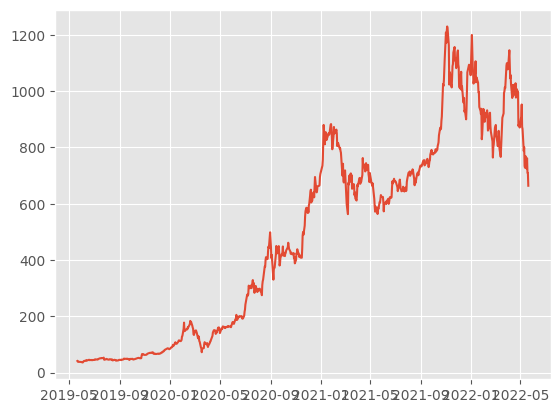

In [108]:
plt.plot(stock_data.Close)

(array([228.,  57.,  38.,  59.,  50., 127.,  81.,  44.,  59.,  15.]),
 array([  35.79399872,  155.20560226,  274.61720581,  394.02880936,
         513.4404129 ,  632.85201645,  752.26362   ,  871.67522354,
         991.08682709, 1110.49843063, 1229.91003418]),
 <BarContainer object of 10 artists>)

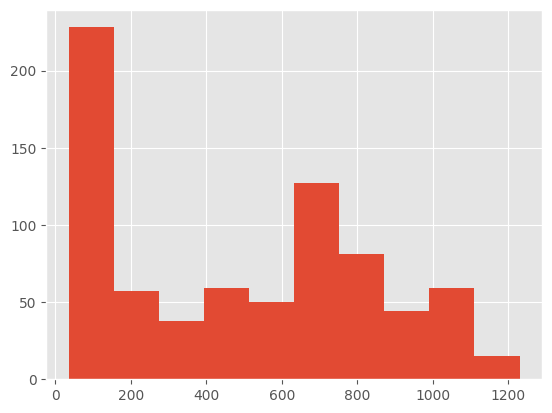

In [109]:
plt.hist(stock_data)

<ipython-input-110-980256126219>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(stock_data.Close)


<Axes: xlabel='Close', ylabel='Density'>

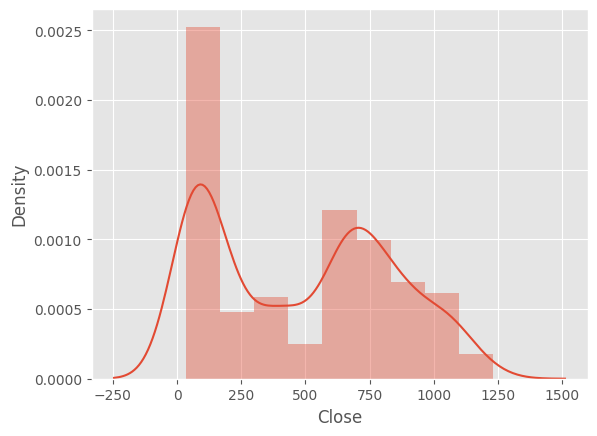

In [110]:
sns.distplot(stock_data.Close)

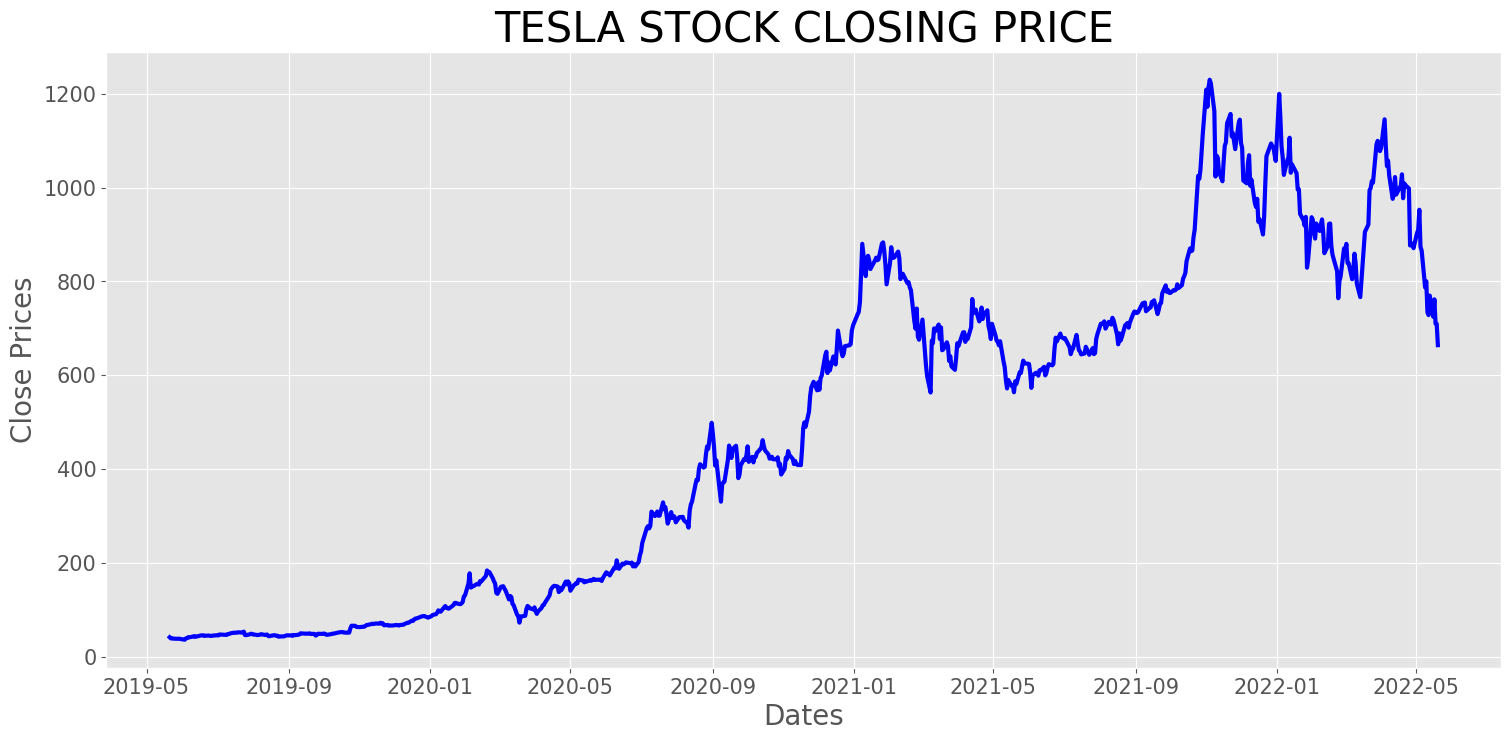

In [111]:
## PLOTTING CLOSE PRICE
plt.style.use('ggplot')
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel("Dates",fontsize=20)
plt.xticks(fontsize=15)
plt.ylabel("Close Prices",fontsize=20)
plt.yticks(fontsize=15)
plt.plot(stock_data["Close"],linewidth=3,color="blue")
plt.title("TESLA STOCK CLOSING PRICE",fontsize=30)
plt.show()


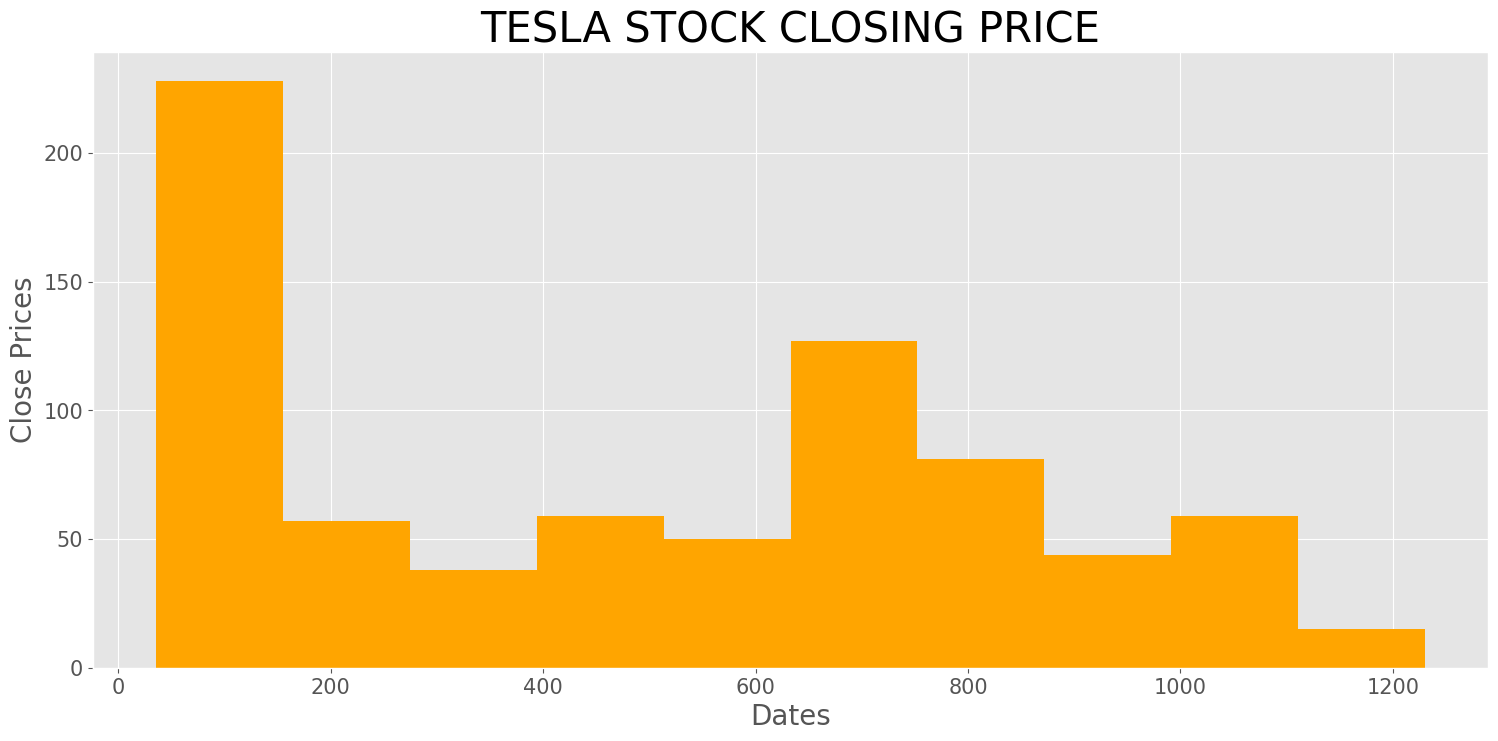

In [112]:
## PLOTTING CLOSE PRICE
plt.style.use('ggplot')
plt.figure(figsize=(18,8))
plt.grid(True)
plt.xlabel("Dates",fontsize=20)
plt.xticks(fontsize=15)
plt.ylabel("Close Prices",fontsize=20)
plt.yticks(fontsize=15)
plt.hist(stock_data["Close"],linewidth=3,color="orange")
plt.title("TESLA STOCK CLOSING PRICE",fontsize=30)
plt.show()


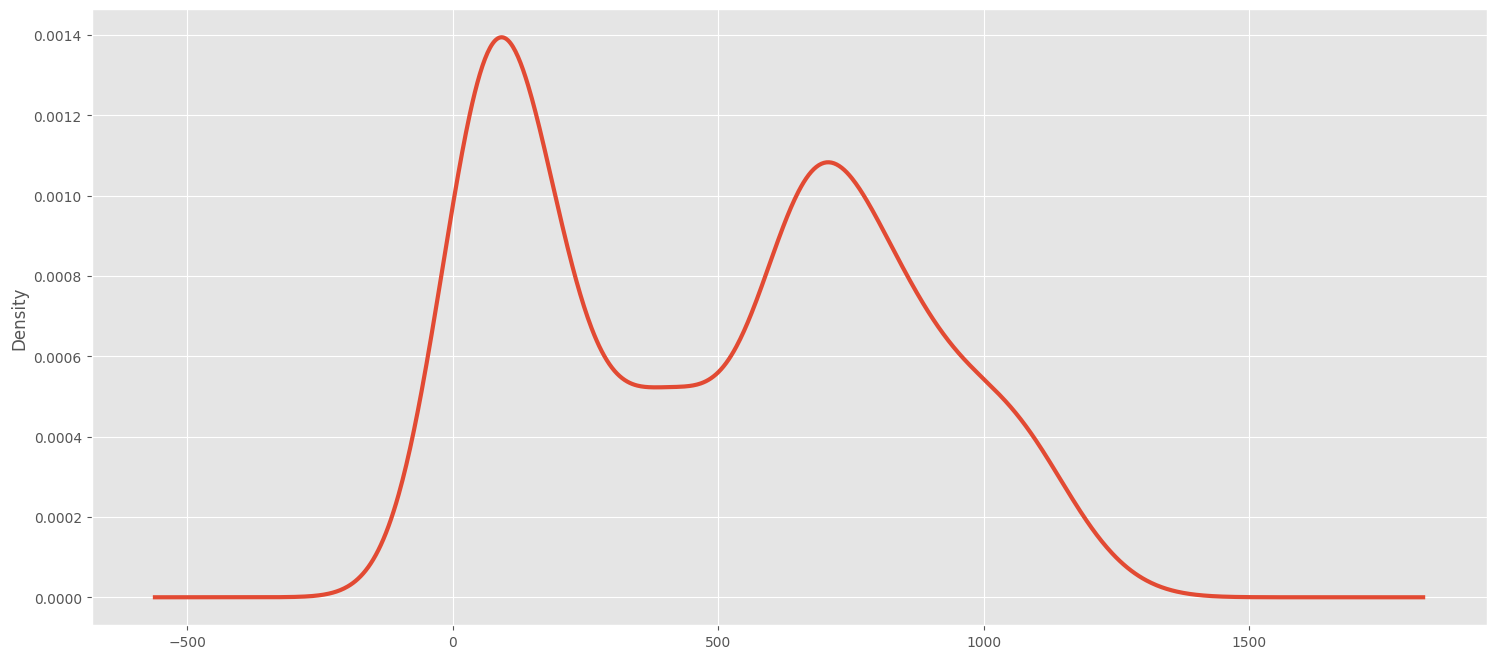

In [113]:
## DISTRIBUTION OF THE CLOSE PRICE

df_close=stock_data["Close"]
df_close.plot(kind="kde",figsize=(18,8),linewidth=3)
plt.grid("both")

In [114]:
rolmean=stock_data["Close"].rolling(365).mean()
rolmean

Date
2019-05-21           NaN
2019-05-22           NaN
2019-05-23           NaN
2019-05-24           NaN
2019-05-28           NaN
                 ...    
2022-05-16    812.017943
2022-05-17    812.478847
2022-05-18    812.782327
2022-05-19    812.967697
2022-05-20    813.006108
Name: Close, Length: 758, dtype: float64

In [115]:
rolstd=stock_data["Close"].rolling(365).std()
rolmean

Date
2019-05-21           NaN
2019-05-22           NaN
2019-05-23           NaN
2019-05-24           NaN
2019-05-28           NaN
                 ...    
2022-05-16    812.017943
2022-05-17    812.478847
2022-05-18    812.782327
2022-05-19    812.967697
2022-05-20    813.006108
Name: Close, Length: 758, dtype: float64

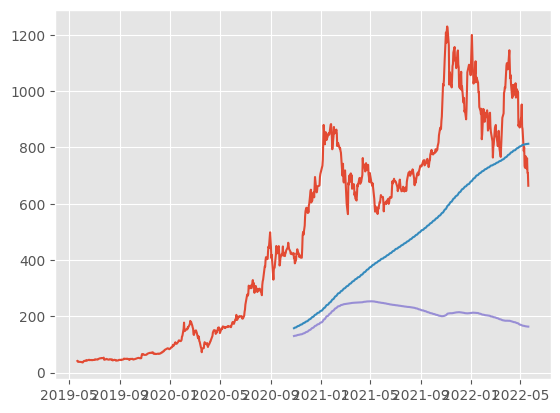

In [116]:
plt.plot(stock_data.Close)
plt.plot(rolmean)
plt.plot(rolstd)

In [117]:
from statsmodels.tsa.stattools import adfuller
adft=adfuller(stock_data.Close)
adft

(-1.3630085817037492,
 0.5998762543050696,
 9,
 748,
 {'1%': -3.43912257105195,
  '5%': -2.8654117005229844,
  '10%': -2.568831705010152},
 6794.359259220987)

In [118]:
pd.Series(adft[0:4],index=["test stats","p value","lag","data points"])

test stats      -1.363009
p value          0.599876
lag              9.000000
data points    748.000000
dtype: float64

In [119]:
#Test for staionarity
def test_stationarity(timeseries):
    # Determing rolling statistics
    rolmean = timeseries.rolling(48).mean() # rolling mean
    rolstd = timeseries.rolling(48).std() # rolling standard deviation
    # Plot rolling statistics:
    plt.figure(figsize = (18,8))
    plt.grid('both')
    plt.plot(timeseries, color='blue',label='Original', linewidth = 3)
    plt.plot(rolmean, color='red', label='Rolling Mean',linewidth = 3)
    plt.plot(rolstd, color='black', label = 'Rolling Std',linewidth = 4)
    plt.legend(loc='best', fontsize = 20, shadow=True,facecolor='lightpink',edgecolor = 'k')
    plt.title('Rolling Mean and Standard Deviation', fontsize = 25)
    plt.xticks(fontsize = 15)
    plt.yticks(fontsize = 15)
    plt.show(block=False)

    print("Results of dickey fuller test")
    adft = adfuller(timeseries,autolag='AIC')
    # output for dft will give us without defining what the values are.
    # hence we manually write what values does it explains using a for loop
    output = pd.Series(adft[0:4],index=['Test Statistics','p-value','No. of lags used','Number of observations used'])
    for key,values in adft[4].items():
        output['critical value (%s)'%key] =  values
    print(output)


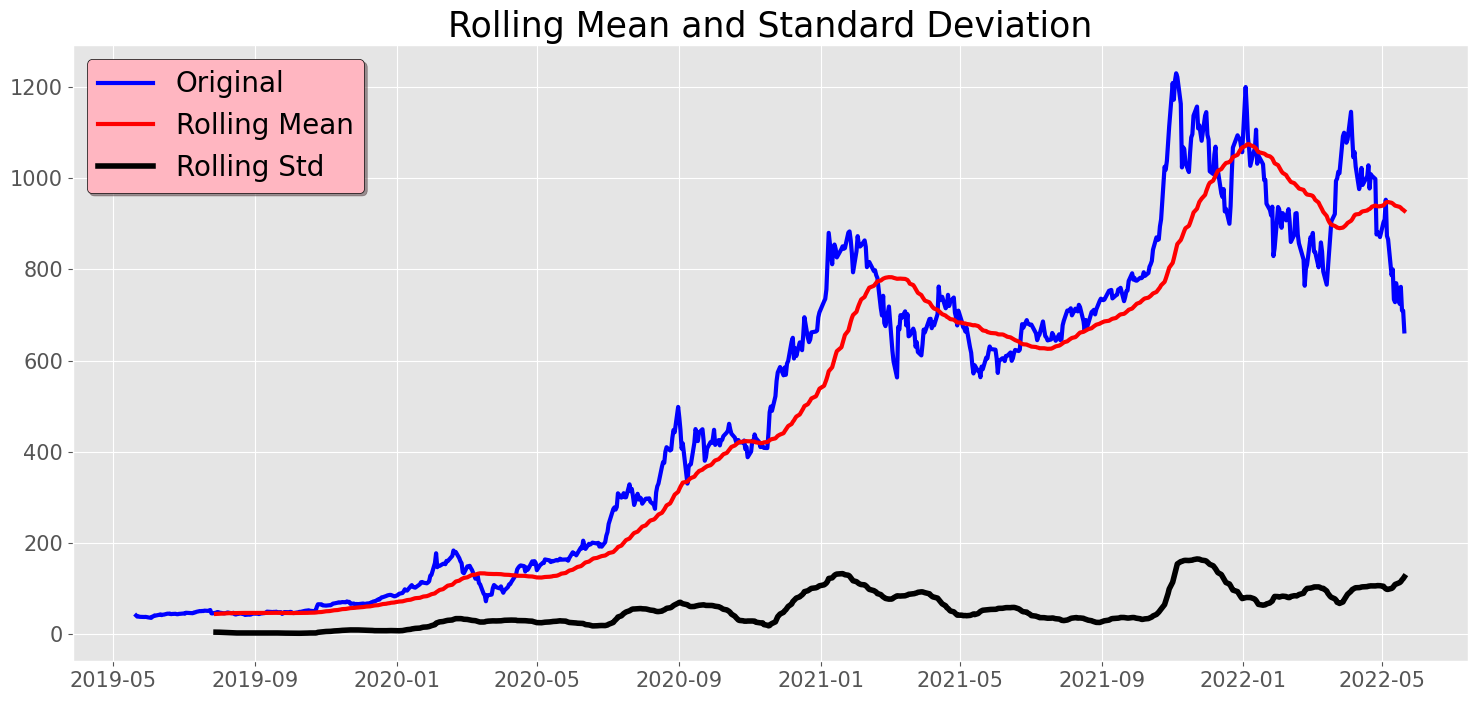

Results of dickey fuller test
Test Statistics                 -1.363009
p-value                          0.599876
No. of lags used                 9.000000
Number of observations used    748.000000
critical value (1%)             -3.439123
critical value (5%)             -2.865412
critical value (10%)            -2.568832
dtype: float64


In [120]:
test_stationarity(stock_data.Close)

<Axes: >

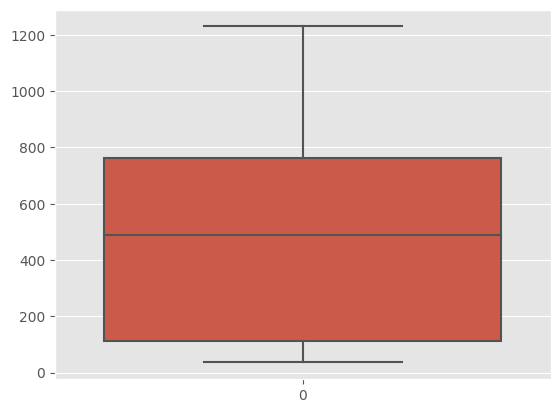

In [121]:
## checking for outliers

sns.boxplot(stock_data.Close)

In [122]:
## TIME SERIES DECOMPOSITION

from statsmodels.tsa.seasonal import seasonal_decompose

result=seasonal_decompose(stock_data[["Close"]],period=12)


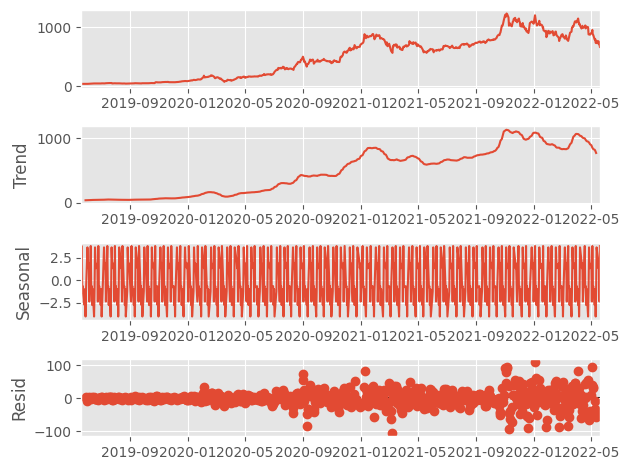

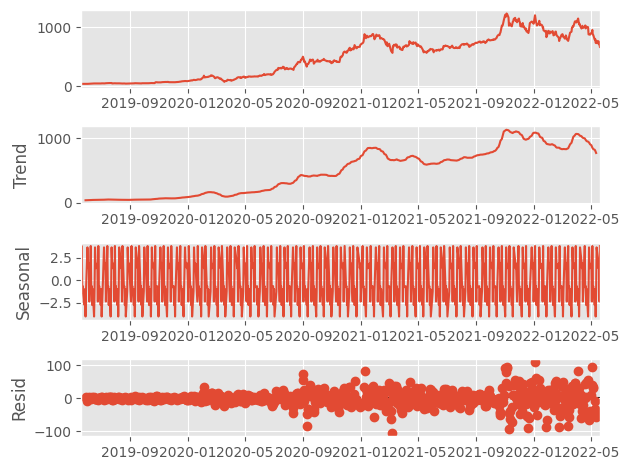

In [123]:
result.plot()

In [124]:
result.seasonal

Date
2019-05-21   -2.346452
2019-05-22    3.768884
2019-05-23   -0.777006
2019-05-24   -0.654226
2019-05-28   -2.737845
                ...   
2022-05-16    2.149519
2022-05-17    1.323680
2022-05-18    1.837638
2022-05-19   -2.346452
2022-05-20    3.768884
Name: seasonal, Length: 758, dtype: float64

In [125]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

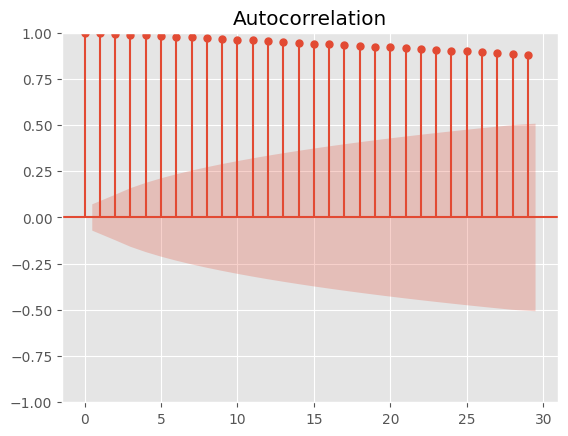

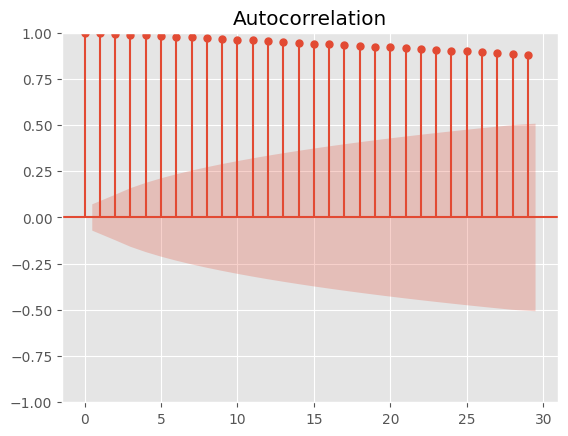

In [126]:
plot_acf(stock_data.Close)


/usr/local/lib/python3.10/dist-packages/statsmodels/graphics/tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


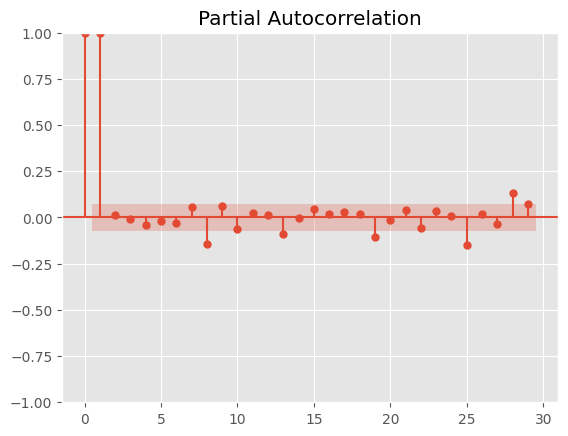

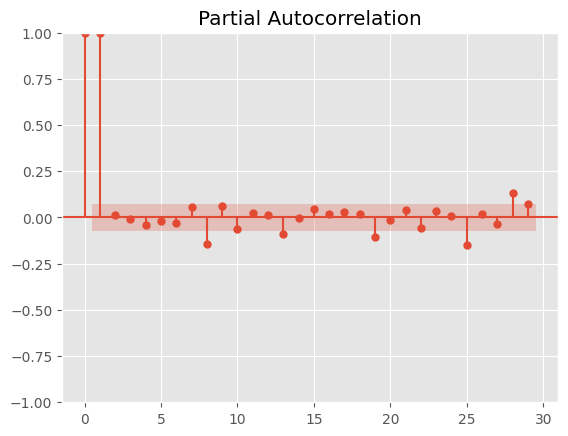

In [127]:
plot_pacf(stock_data.Close)

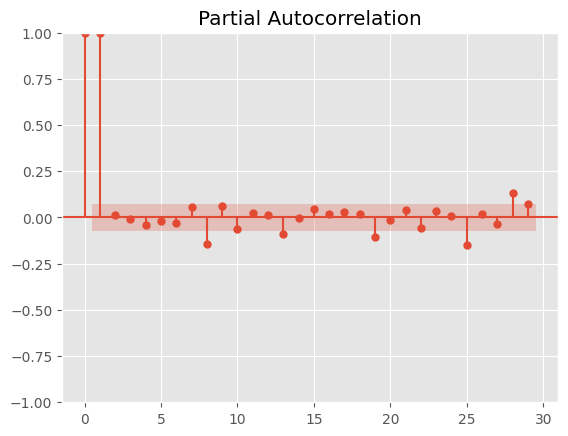

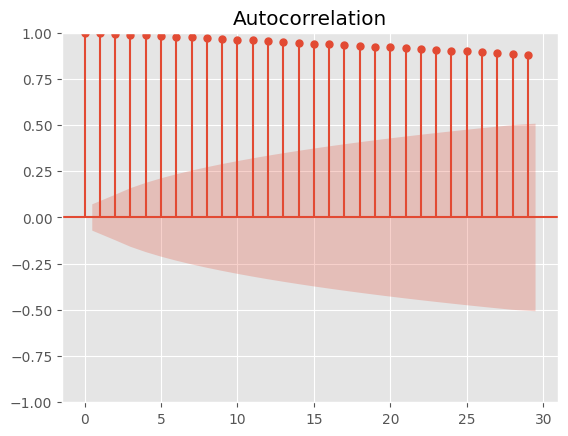

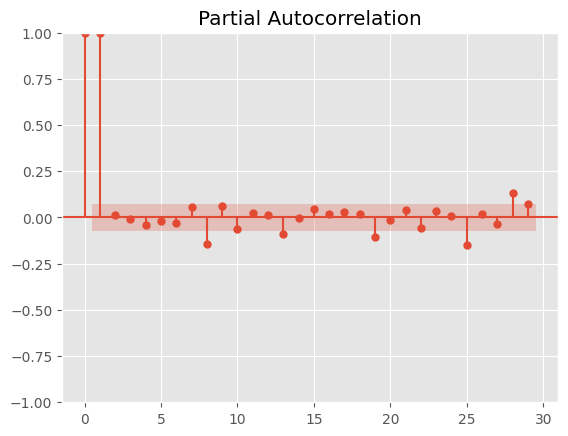

In [128]:
plot_acf(stock_data.Close)
plot_pacf(stock_data.Close)

In [130]:
##PREPROCESSING

#CONVERTING FROM NON STATIONARY TO STATIONARY

df_close=stock_data["Close"]


In [135]:
df_close=df_close.diff()
df_close=df_close.dropna()

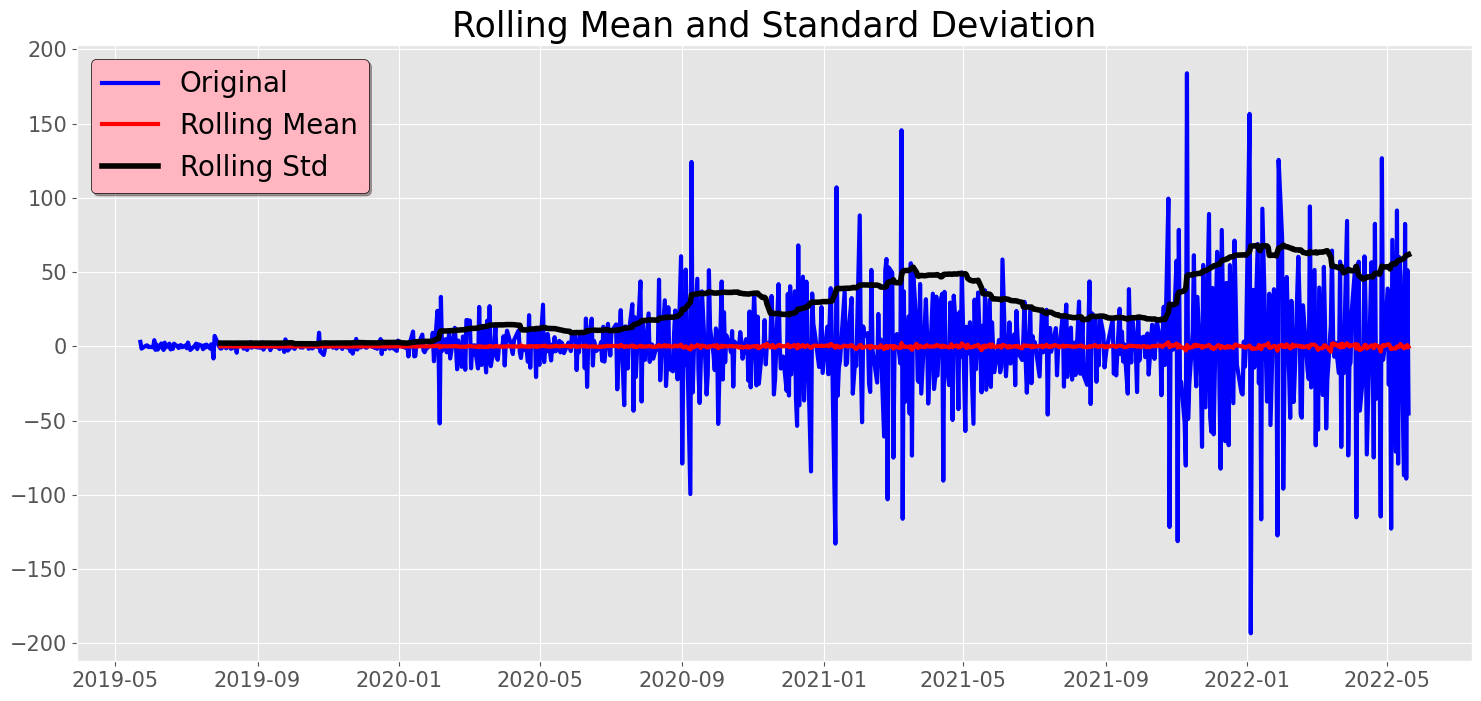

Results of dickey fuller test
Test Statistics               -1.047053e+01
p-value                        1.287880e-18
No. of lags used               1.900000e+01
Number of observations used    7.360000e+02
critical value (1%)           -3.439266e+00
critical value (5%)           -2.865475e+00
critical value (10%)          -2.568865e+00
dtype: float64


In [136]:
test_stationarity(df_close)

In [141]:
train_data=df_close[0:-60]## training

In [142]:
df_close.shape


(756,)

In [143]:
test_data=df_close[-60:]## testing

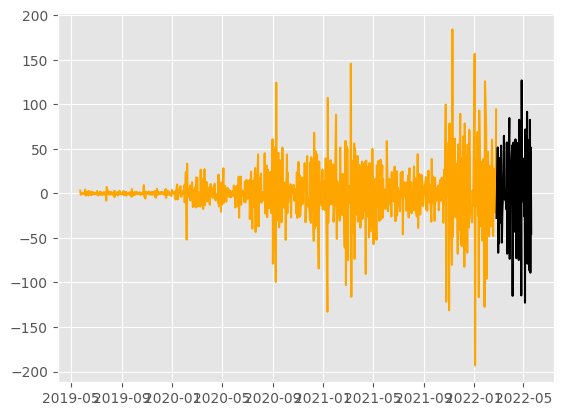

In [148]:
plt.plot(train_data,"orange")
plt.plot(test_data,"black")